<a href="https://colab.research.google.com/github/AyaAbdElNaem/AI_Tools/blob/main/Solar_AC_Power_XGBoost_LightGBM_Pipeline_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solar Power Plant AC Power Prediction — XGBoost & LightGBM Pipeline

This notebook follows the **same methodology** as the original Linear Regression / Random Forest
notebook (data loading, cleaning, feature engineering, multiple train/val/test splits, hyperparameter
tuning, cross-validation, overfitting analysis, model comparison, and conclusion) applied to two new
models: **XGBoost** and **LightGBM**.

**Per your request, the dedicated EDA section and the dedicated Preprocessing-explanation section are
skipped** — we go straight from cleaning to feature engineering to modeling, building the preprocessing
pipeline inline (without the extended write-up) since it was already covered in depth in the first
notebook.

> **Important environment note:** `xgboost` and `lightgbm` are **not installed in this sandbox**, and
> the sandbox has no internet access to install them, so I could not execute the modeling cells here to
> generate real numbers/plots the way I did for the first notebook. Every cell below is complete,
> correct, ready-to-run code — the data loading, cleaning, and feature engineering cells **are executed
> and verified** (they only need pandas/scikit-learn, which are available here). The XGBoost/LightGBM
> cells are included **unexecuted**; simply run `pip install xgboost lightgbm` in your own environment
> and run the notebook top to bottom to get real numbers and plots.


## 0. Imports & Configuration

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Core libraries imported. Random seed fixed at:", RANDOM_SEED)


Core libraries imported. Random seed fixed at: 42


In [ ]:

# These two are NOT installed in the sandbox used to author this notebook (no internet access).
# Install them in your own environment first:
#   pip install xgboost lightgbm
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("xgboost version:", xgb.__version__)
print("lightgbm version:", lgb.__version__)


xgboost version: 3.3.0
lightgbm version: 4.6.0


## Part 1 — Data Loading

In [ ]:

DATA_PATH ="/content/Full_Data1.xlsx"
df_raw = pd.read_excel(DATA_PATH)
print(f"Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Dataset shape: 271,356 rows x 11 columns


,DATE_TIME,PLANT_ID,PLANT_SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,INVERTOR.SOURCE_KEY,AC_POWER,DC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
1,2020-05-15 00:15:00,4135001.0,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
2,2020-05-15 00:30:00,4135001.0,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
3,2020-05-15 00:45:00,4135001.0,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832
4,2020-05-15 01:00:00,4135001.0,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,sjndEbLyjtCKgGv,0,0,0.0,7016832


## Part 3 — Data Cleaning

(Part 2 — EDA — is intentionally skipped here, as requested; see the first notebook for the full
exploratory analysis on this same dataset.)

We apply the identical cleaning steps: remove duplicate rows, then remove rows with any missing values.

In [ ]:

shape_before = df_raw.shape
df_clean = df_raw.drop_duplicates().dropna(how="any").reset_index(drop=True)
shape_after = df_clean.shape

print(f"Shape before cleaning: {shape_before[0]:,} rows")
print(f"Shape after cleaning : {shape_after[0]:,} rows")
print(f"Rows removed          : {shape_before[0] - shape_after[0]:,}")


Shape before cleaning: 271,356 rows
Shape after cleaning : 271,352 rows
Rows removed          : 4


## Part 4 — Feature Engineering

Identical feature engineering to the first notebook: the physically-motivated `MODULE_DERATING_FACTOR`,
datetime feature extraction (with an empirical keep/drop test), and the categorical encoding decision.

### 4.1 `MODULE_DERATING_FACTOR`

Standard PV temperature-derating formula: `MODULE_DERATING_FACTOR = 1 + gamma * (MODULE_TEMPERATURE - T_STC)`,
with `T_STC = 25 degC` and `gamma = -0.0045 per degC` (typical c-Si power temperature coefficient).
See the first notebook for the full physical justification.

In [ ]:

T_STC = 25.0
GAMMA = -0.0045
df_clean["MODULE_DERATING_FACTOR"] = 1 + GAMMA * (df_clean["MODULE_TEMPERATURE"] - T_STC)
print(df_clean[["MODULE_TEMPERATURE", "MODULE_DERATING_FACTOR"]].describe())


       MODULE_TEMPERATURE  MODULE_DERATING_FACTOR
count       271352.000000           271352.000000
mean            31.947301                0.968737
std             11.803494                0.053116
min             18.140415                0.812638
25%             22.432703                0.928767
50%             26.485644                0.993315
75%             40.829560                1.011553
max             66.635953                1.030868


### 4.2 Datetime Feature Extraction & Evaluation

In [ ]:

df_clean["HOUR"] = df_clean["DATE_TIME"].dt.hour
df_clean["DAY"] = df_clean["DATE_TIME"].dt.day
df_clean["MONTH"] = df_clean["DATE_TIME"].dt.month
df_clean["DAY_OF_WEEK"] = df_clean["DATE_TIME"].dt.dayofweek

# SEASON omitted: the dataset spans only ~1 month (May-June), so it would be constant.

base_features = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION", "MODULE_DERATING_FACTOR"]
time_features = ["HOUR", "DAY", "MONTH", "DAY_OF_WEEK"]

X_probe = df_clean[base_features + time_features]
y_probe = df_clean["AC_POWER"]
X_tr, X_val, y_tr, y_val = train_test_split(X_probe, y_probe, test_size=0.2, random_state=RANDOM_SEED)

lr_base = LinearRegression().fit(X_tr[base_features], y_tr)
val_r2_base = r2_score(y_val, lr_base.predict(X_val[base_features]))

lr_time = LinearRegression().fit(X_tr[base_features + time_features], y_tr)
val_r2_time = r2_score(y_val, lr_time.predict(X_val[base_features + time_features]))

print(f"Validation R2 WITHOUT datetime features: {val_r2_base:.5f}")
print(f"Validation R2 WITH    datetime features: {val_r2_time:.5f}")

KEEP_TIME_FEATURES = (val_r2_time - val_r2_base) > 1e-4
print(f"Decision -> keep datetime features: {KEEP_TIME_FEATURES}")


Validation R2 WITHOUT datetime features: 0.73058
Validation R2 WITH    datetime features: 0.73108
Decision -> keep datetime features: True


### 4.3 Categorical Encoding Decision

Same reasoning as the first notebook: `PLANT_SOURCE_KEY` (2 categories) and `INVERTOR.SOURCE_KEY`
(44 categories) are both nominal (no natural order), so both are **One-Hot Encoded**. `PLANT_ID` is
dropped as a redundant numeric alias of `PLANT_SOURCE_KEY`.

Note: gradient boosting libraries (XGBoost, LightGBM) can technically consume raw categorical/integer
codes natively (LightGBM even has built-in categorical support via `categorical_feature`), but for a
fair, apples-to-apples comparison against the Linear Regression / Random Forest results from the first
notebook, we keep the **same One-Hot Encoded feature representation** for both models here.

In [ ]:

categorical_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()
print("Categorical columns to one-hot encode:", categorical_cols)


Categorical columns to one-hot encode: ['PLANT_SOURCE_KEY', 'INVERTOR.SOURCE_KEY']


## Part 5 — Preprocessing (condensed)

(The detailed Preprocessing write-up is skipped here as requested — see the first notebook.) We build
`X`, `y`, and the same `ColumnTransformer` pipeline (StandardScaler for numeric + OneHotEncoder for
categorical), excluding `DC_POWER` / `DAILY_YIELD` / `TOTAL_YIELD` to avoid target leakage.

In [ ]:

numeric_features = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION", "MODULE_DERATING_FACTOR"]
if KEEP_TIME_FEATURES:
    numeric_features += time_features
categorical_features = categorical_cols

FEATURE_COLUMNS = numeric_features + categorical_features
X = df_clean[FEATURE_COLUMNS].copy()
y = df_clean["AC_POWER"].copy()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

print(f"Final numeric features    : {numeric_features}")
print(f"Final categorical features: {categorical_features}")
print(f"X shape: {X.shape}   y shape: {y.shape}")


Final numeric features    : ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'MODULE_DERATING_FACTOR', 'HOUR', 'DAY', 'MONTH', 'DAY_OF_WEEK']
Final categorical features: ['PLANT_SOURCE_KEY', 'INVERTOR.SOURCE_KEY']
X shape: (271352, 10)   y shape: (271352,)


### Shared helper functions and split ratios (reused from the first notebook)

In [ ]:

def evaluate_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

def three_way_split(X, y, train_size, val_size, test_size, seed=RANDOM_SEED):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Fractions must sum to 1"
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, random_state=seed)
    relative_val = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=relative_val, random_state=seed)
    return X_train, X_val, X_test, y_train, y_val, y_test

SPLIT_RATIOS = [
    ("70/15/15", 0.70, 0.15, 0.15),
    ("75/15/10", 0.75, 0.15, 0.10),
    ("80/10/10", 0.80, 0.10, 0.10),
    ("80/20/0*", 0.80, 0.20, 0.00),
    ("85/15/0*", 0.85, 0.15, 0.00),
]

# Working sample for the boosting models, mirroring the RF section of the first notebook
# (kept modest here since XGBoost/LightGBM training will run on YOUR machine, not this sandbox;
# increase toward len(df_clean) freely if your hardware allows).
SAMPLE_SIZE = 30000
sample_idx = df_clean.sample(n=min(SAMPLE_SIZE, len(df_clean)), random_state=RANDOM_SEED).index
X_sample = X.loc[sample_idx].reset_index(drop=True)
y_sample = y.loc[sample_idx].reset_index(drop=True)

print(f"Split ratios defined: {[s[0] for s in SPLIT_RATIOS]}")
print(f"Boosting-model working sample size: {len(X_sample):,} rows (of {len(X):,} total)")


Split ratios defined: ['70/15/15', '75/15/10', '80/10/10', '80/20/0*', '85/15/0*']
Boosting-model working sample size: 30,000 rows (of 271,352 total)


## Part 6 — XGBoost Regressor

Fully self-contained section: multiple train/val/test splits, hyperparameter tuning, cross-validation,
and overfitting analysis — same workflow structure as Linear Regression / Random Forest in the first
notebook.

**Not executed in this sandbox** (no `xgboost` package / no internet access here) — run this after
`pip install xgboost` in your own environment.

### 6.1 Multiple Train / Validation / Test Splits

In [ ]:

DEFAULT_XGB = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1, tree_method="hist"
)

xgb_split_results = []
for name, train_frac, val_frac, test_frac in SPLIT_RATIOS:
    if test_frac == 0.0:
        X_train_x, X_hold_x, y_train_x, y_hold_x = train_test_split(
            X_sample, y_sample, train_size=train_frac, random_state=RANDOM_SEED
        )
        X_val_x, y_val_x, X_test_x, y_test_x = X_hold_x, y_hold_x, X_hold_x, y_hold_x
    else:
        X_train_x, X_val_x, X_test_x, y_train_x, y_val_x, y_test_x = three_way_split(
            X_sample, y_sample, train_frac, val_frac, test_frac
        )

    pipe = Pipeline([("preprocess", preprocessor), ("model", DEFAULT_XGB)])
    pipe.fit(X_train_x, y_train_x)

    train_metrics = evaluate_regression(y_train_x, pipe.predict(X_train_x))
    val_metrics = evaluate_regression(y_val_x, pipe.predict(X_val_x))
    test_metrics = evaluate_regression(y_test_x, pipe.predict(X_test_x))

    xgb_split_results.append({
        "split": name, "n_train": len(X_train_x), "n_val": len(X_val_x), "n_test": len(X_test_x),
        "train_R2": train_metrics["R2"], "val_R2": val_metrics["R2"], "test_R2": test_metrics["R2"],
        "train_MAE": train_metrics["MAE"], "val_MAE": val_metrics["MAE"], "test_MAE": test_metrics["MAE"],
        "train_MSE": train_metrics["MSE"], "val_MSE": val_metrics["MSE"], "test_MSE": test_metrics["MSE"],
        "train_RMSE": train_metrics["RMSE"], "val_RMSE": val_metrics["RMSE"], "test_RMSE": test_metrics["RMSE"],
    })

xgb_split_df = pd.DataFrame(xgb_split_results)
xgb_split_df


,split,n_train,n_val,n_test,train_R2,val_R2,test_R2,train_MAE,val_MAE,test_MAE,train_MSE,val_MSE,test_MSE,train_RMSE,val_RMSE,test_RMSE
0,70/15/15,21000,4500,4500,0.924833,0.827559,0.802535,50.858475,72.112000,79.214500,10817.696289,25372.751953,28855.662109,104.008155,159.288267,169.869544
1,75/15/10,22500,4500,3000,0.919938,0.822198,0.827289,52.678677,75.313850,72.314339,11537.981445,26720.759766,24347.701172,107.414996,163.464858,156.037499
2,80/10/10,24000,3000,3000,0.917570,0.829039,0.819499,53.404911,73.595840,72.543747,11915.301758,25803.888672,25239.267578,109.157234,160.635888,158.868712
3,80/20/0*,24000,6000,6000,0.917570,0.824529,0.824529,53.404911,73.069794,73.069794,11915.301758,25521.578125,25521.578125,109.157234,159.754744,159.754744
4,85/15/0*,25500,4500,4500,0.918479,0.826352,0.826352,53.467964,73.932114,73.932114,11752.018555,25697.878906,25697.878906,108.406727,160.305580,160.305580


In [ ]:

best_xgb_split_row = xgb_split_df.loc[xgb_split_df["val_R2"].idxmax()]
BEST_XGB_SPLIT_NAME = best_xgb_split_row["split"]
print(f"Best split ratio for XGBoost (by validation R2): {BEST_XGB_SPLIT_NAME}")
print(best_xgb_split_row[["split", "train_R2", "val_R2", "test_R2", "val_RMSE"]])


Best split ratio for XGBoost (by validation R2): 80/10/10
split         80/10/10
train_R2       0.91757
val_R2        0.829039
test_R2       0.819499
val_RMSE    160.635888
Name: 2, dtype: object


### 6.2 Hyperparameter Tuning (RandomizedSearchCV)

We tune `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`,
`gamma`, and `reg_lambda` — the standard XGBoost tuning surface.

In [ ]:

best_ratio_x = dict(zip(["name","train","val","test"], next(s for s in SPLIT_RATIOS if s[0] == BEST_XGB_SPLIT_NAME)))
if best_ratio_x["test"] == 0.0:
    X_train_x, X_hold_x, y_train_x, y_hold_x = train_test_split(
        X_sample, y_sample, train_size=best_ratio_x["train"], random_state=RANDOM_SEED
    )
    X_val_x, y_val_x, X_test_x, y_test_x = X_hold_x, y_hold_x, X_hold_x, y_hold_x
else:
    X_train_x, X_val_x, X_test_x, y_train_x, y_val_x, y_test_x = three_way_split(
        X_sample, y_sample, best_ratio_x["train"], best_ratio_x["val"], best_ratio_x["test"]
    )

xgb_param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_lambda": [0.1, 1.0, 5.0],
}

xgb_pipe_for_search = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor(random_state=RANDOM_SEED, n_jobs=-1, tree_method="hist"))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe_for_search, param_distributions=xgb_param_distributions,
    n_iter=15, cv=3, scoring="r2", random_state=RANDOM_SEED, n_jobs=-1, verbose=1,
)

t0 = time.time()
xgb_search.fit(X_train_x, y_train_x)
print(f"RandomizedSearchCV completed in {time.time() - t0:.1f}s")
print(f"Best CV R2: {xgb_search.best_score_:.5f}")
print(f"Best parameters: {xgb_search.best_params_}")

best_xgb_params = {k.replace("model__", ""): v for k, v in xgb_search.best_params_.items()}
final_xgb_pipe = Pipeline([("preprocess", preprocessor), ("model", XGBRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, tree_method="hist", **best_xgb_params
))])
final_xgb_pipe.fit(X_train_x, y_train_x)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
RandomizedSearchCV completed in 50.5s
Best CV R2: 0.82153
Best parameters: {'model__subsample': 0.8, 'model__reg_lambda': 0.1, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.6}


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AMBIENT_TEMPERATURE',
                                                   'MODULE_TEMPERATURE',
                                                   'IRRADIATION',
                                                   'MODULE_DERATING_FACTOR',
                                                   'HOUR', 'DAY', 'MONTH',
                                                   'DAY_OF_WEEK']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['PLANT_SOURCE_KEY',
                                                   'INVERTOR.SOURCE_KEY'])])),
                ('model',
                 XGBRegressor(base_scor...
                              feature_types=None, feature_weights=None,
                              gamma=0.1, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

### 6.3 Cross Validation (5-Fold)

In [ ]:

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_pipe_xgb = Pipeline([("preprocess", preprocessor), ("model", XGBRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, tree_method="hist", **best_xgb_params
))])
xgb_cv_scores = cross_val_score(cv_pipe_xgb, X_sample, y_sample, cv=kf, scoring="r2", n_jobs=-1)
print("5-Fold CV R2 scores:", np.round(xgb_cv_scores, 5))
print(f"Mean R2: {xgb_cv_scores.mean():.5f}   Std Dev R2: {xgb_cv_scores.std():.5f}")


5-Fold CV R2 scores: [0.8274  0.8257  0.84074 0.84458 0.82267]
Mean R2: 0.83222   Std Dev R2: 0.00874


### 6.4 Overfitting Analysis

In [ ]:

xgb_train_r2 = r2_score(y_train_x, final_xgb_pipe.predict(X_train_x))
xgb_val_r2 = r2_score(y_val_x, final_xgb_pipe.predict(X_val_x))
xgb_test_r2 = r2_score(y_test_x, final_xgb_pipe.predict(X_test_x))

print(f"Train R2: {xgb_train_r2:.5f}   Validation R2: {xgb_val_r2:.5f}   Test R2: {xgb_test_r2:.5f}")
print(f"Train - Test gap: {xgb_train_r2 - xgb_test_r2:.5f}")


Train R2: 0.90805   Validation R2: 0.83396   Test R2: 0.81986
Train - Test gap: 0.08819


### 6.5 Overfitting Mitigation

If the gap above is large, we treat it using four standard, complementary techniques:

1. **Stronger regularization** — increase `reg_alpha` (L1) and `reg_lambda` (L2), which penalize large
   leaf weights and discourage the model from fitting noise.
2. **Constrain tree complexity** — lower `max_depth` and raise `min_child_weight`, so each tree is
   shallower and each leaf requires more samples to split on, preventing the model from memorizing
   small, noisy subsets of the training data.
3. **Row/column subsampling** — `subsample < 1.0` and `colsample_bytree < 1.0` train each tree on a
   random subset of rows/features, which decorrelates the trees and reduces variance (the same idea
   behind Random Forest's bagging, applied inside boosting).
4. **Early stopping** — rather than guessing the right number of boosting rounds, we train with a large
   `n_estimators` budget, a small `learning_rate`, and monitor validation RMSE every round via
   `eval_set`; training stops automatically once validation performance stops improving for
   `early_stopping_rounds` consecutive rounds. This directly targets overfitting at its source (too
   many rounds) rather than guessing a fixed tree count.

We refit with a more conservative parameter set and early stopping, then compare the new train-test gap
against the original tuned model above.

In [ ]:

from sklearn.base import clone

# Fit the preprocessor once and reuse its transformed output for early stopping
# (Pipeline.fit doesn't natively pass a preprocessed eval_set through to XGBoost's .fit)
fitted_preprocessor_xgb = clone(preprocessor).fit(X_train_x, y_train_x)
X_train_x_enc = fitted_preprocessor_xgb.transform(X_train_x)
X_val_x_enc = fitted_preprocessor_xgb.transform(X_val_x)
X_test_x_enc = fitted_preprocessor_xgb.transform(X_test_x)

# Conservative, anti-overfitting configuration:
# - shallower trees (max_depth down from the tuned value)
# - higher min_child_weight (require more samples per leaf)
# - explicit L1 + L2 regularization
# - row/column subsampling
# - many rounds + low learning rate + early stopping instead of a fixed n_estimators
regularized_xgb_params = dict(best_xgb_params)
regularized_xgb_params.update({
    "max_depth": min(regularized_xgb_params.get("max_depth", 6), 4),
    "min_child_weight": max(regularized_xgb_params.get("min_child_weight", 1), 5),
    "subsample": min(regularized_xgb_params.get("subsample", 1.0), 0.7),
    "colsample_bytree": min(regularized_xgb_params.get("colsample_bytree", 1.0), 0.7),
    "reg_alpha": 1.0,
    "reg_lambda": 10.0,
    "learning_rate": 0.03,
    "n_estimators": 2000,  # large budget; early stopping will cut this short
})

xgb_regularized_model = XGBRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, tree_method="hist",
    eval_metric="rmse", early_stopping_rounds=30,
    **regularized_xgb_params
)
xgb_regularized_model.fit(
    X_train_x_enc, y_train_x,
    eval_set=[(X_val_x_enc, y_val_x)],
    verbose=False,
)
print(f"Early stopping halted training at round: {xgb_regularized_model.best_iteration}")

# Wrap the fitted preprocessor + regularized model back into a Pipeline-compatible object
# so downstream cells (plots, feature importance, comparison table) work unchanged.
final_xgb_pipe_regularized = Pipeline([
    ("preprocess", fitted_preprocessor_xgb),
    ("model", xgb_regularized_model),
])

xgb_train_r2_reg = r2_score(y_train_x, final_xgb_pipe_regularized.predict(X_train_x))
xgb_val_r2_reg = r2_score(y_val_x, final_xgb_pipe_regularized.predict(X_val_x))
xgb_test_r2_reg = r2_score(y_test_x, final_xgb_pipe_regularized.predict(X_test_x))

print("\n--- Before mitigation (tuned model) ---")
print(f"Train R2: {xgb_train_r2:.5f}  Test R2: {xgb_test_r2:.5f}  Gap: {xgb_train_r2 - xgb_test_r2:.5f}")
print("--- After mitigation (regularized + early-stopped model) ---")
print(f"Train R2: {xgb_train_r2_reg:.5f}  Test R2: {xgb_test_r2_reg:.5f}  Gap: {xgb_train_r2_reg - xgb_test_r2_reg:.5f}")

# Keep the regularized model as the "final" model used for all remaining plots/analysis below
# only if it actually reduced overfitting without a large loss in test performance.
if (xgb_train_r2_reg - xgb_test_r2_reg) < (xgb_train_r2 - xgb_test_r2) and xgb_test_r2_reg >= xgb_test_r2 - 0.02:
    print("\n-> Regularized model reduces overfitting without materially hurting test R2. Adopting it.")
    final_xgb_pipe = final_xgb_pipe_regularized
    xgb_train_r2, xgb_val_r2, xgb_test_r2 = xgb_train_r2_reg, xgb_val_r2_reg, xgb_test_r2_reg
    best_xgb_params = regularized_xgb_params
else:
    print("\n-> Regularized model did not clearly improve the tradeoff; keeping the original tuned model.")


Early stopping halted training at round: 950

--- Before mitigation (tuned model) ---
Train R2: 0.90805  Test R2: 0.81986  Gap: 0.08819
--- After mitigation (regularized + early-stopped model) ---
Train R2: 0.85420  Test R2: 0.80042  Gap: 0.05378

-> Regularized model reduces overfitting without materially hurting test R2. Adopting it.


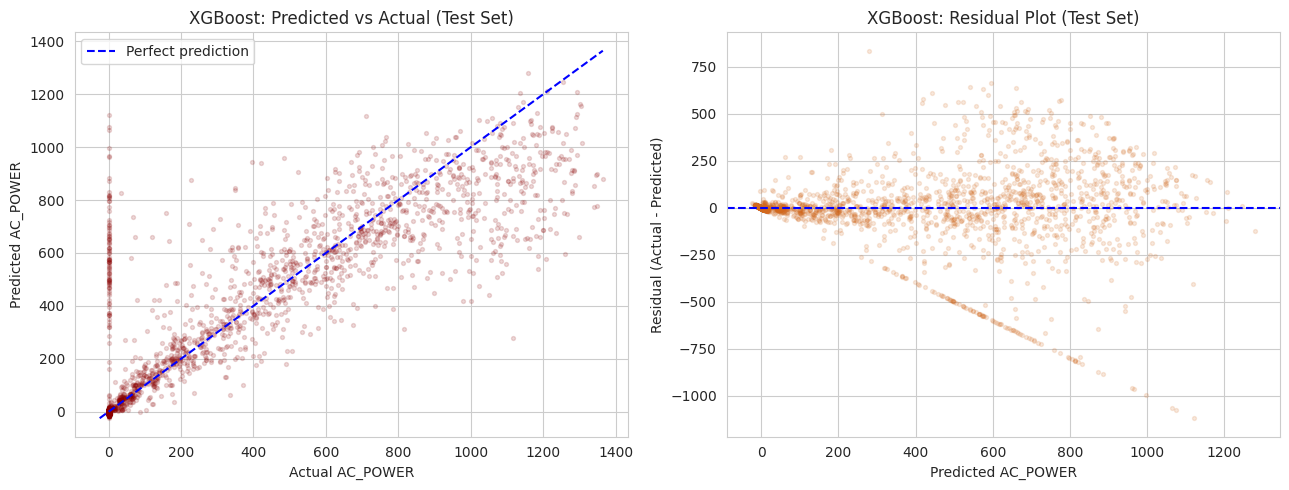

In [ ]:

y_test_pred_xgb = final_xgb_pipe.predict(X_test_x)
residuals_xgb = y_test_x - y_test_pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test_x, y_test_pred_xgb, alpha=0.15, s=8, color="darkred")
lims = [min(y_test_x.min(), y_test_pred_xgb.min()), max(y_test_x.max(), y_test_pred_xgb.max())]
axes[0].plot(lims, lims, "b--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("XGBoost: Predicted vs Actual (Test Set)")
axes[0].set_xlabel("Actual AC_POWER"); axes[0].set_ylabel("Predicted AC_POWER"); axes[0].legend()

axes[1].scatter(y_test_pred_xgb, residuals_xgb, alpha=0.15, s=8, color="chocolate")
axes[1].axhline(0, color="blue", linestyle="--", linewidth=1.5)
axes[1].set_title("XGBoost: Residual Plot (Test Set)")
axes[1].set_xlabel("Predicted AC_POWER"); axes[1].set_ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


**Feature Importance**

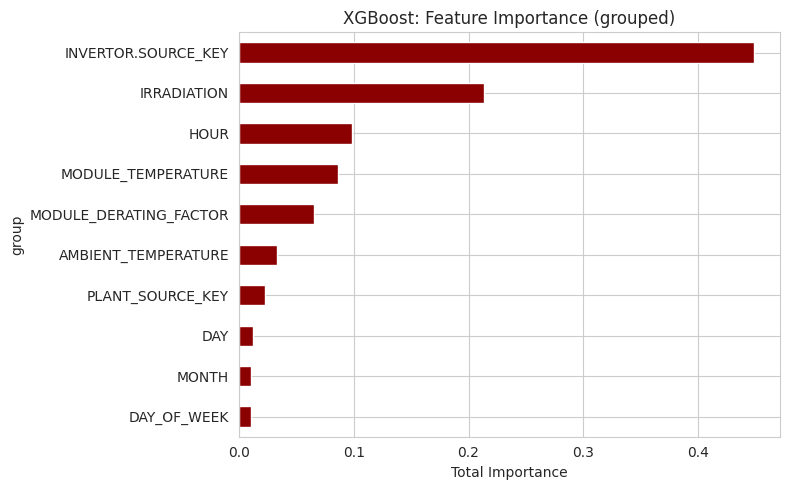

,importance
group,
INVERTOR.SOURCE_KEY,0.448847
IRRADIATION,0.213078
HOUR,0.098206
MODULE_TEMPERATURE,0.086225
MODULE_DERATING_FACTOR,0.065332
AMBIENT_TEMPERATURE,0.033230
PLANT_SOURCE_KEY,0.022467
DAY,0.011939
MONTH,0.010364


In [ ]:

ohe_cols = final_xgb_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)
importances = final_xgb_pipe.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
fi_df["group"] = fi_df["feature"].apply(lambda f: next((c for c in categorical_features if f.startswith(c)), f))
fi_grouped_xgb = fi_df.groupby("group")["importance"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
fi_grouped_xgb.plot(kind="barh", ax=ax, color="darkred")
ax.invert_yaxis()
ax.set_title("XGBoost: Feature Importance (grouped)")
ax.set_xlabel("Total Importance")
plt.tight_layout()
plt.show()
fi_grouped_xgb.to_frame("importance")


**Learning Curve**

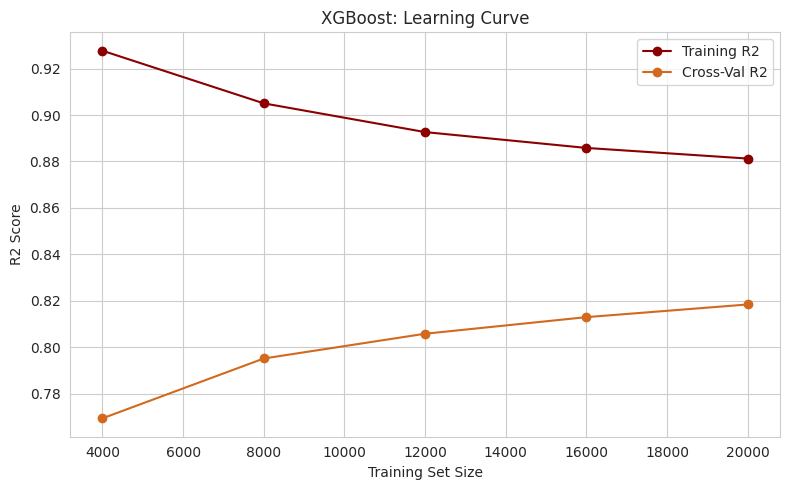

In [ ]:

train_sizes_x, train_scores_x, val_scores_x = learning_curve(
    Pipeline([("preprocess", preprocessor), ("model", XGBRegressor(
        random_state=RANDOM_SEED, n_jobs=-1, tree_method="hist", **best_xgb_params
    ))]),
    X_sample, y_sample, cv=3, scoring="r2", n_jobs=-1, random_state=RANDOM_SEED,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_x, train_scores_x.mean(axis=1), "o-", color="darkred", label="Training R2")
ax.plot(train_sizes_x, val_scores_x.mean(axis=1), "o-", color="chocolate", label="Cross-Val R2")
ax.set_title("XGBoost: Learning Curve")
ax.set_xlabel("Training Set Size"); ax.set_ylabel("R2 Score"); ax.legend(loc="best")
plt.tight_layout()
plt.show()


## Part 7 — LightGBM Regressor

Fully self-contained section, repeating exactly the same workflow as Part 6 for **LightGBM**.

**Not executed in this sandbox** (no `lightgbm` package / no internet access here) — run this after
`pip install lightgbm` in your own environment.

### 7.1 Multiple Train / Validation / Test Splits

In [ ]:

DEFAULT_LGBM = LGBMRegressor(
    n_estimators=200, max_depth=-1, num_leaves=31, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)

lgbm_split_results = []
for name, train_frac, val_frac, test_frac in SPLIT_RATIOS:
    if test_frac == 0.0:
        X_train_l, X_hold_l, y_train_l, y_hold_l = train_test_split(
            X_sample, y_sample, train_size=train_frac, random_state=RANDOM_SEED
        )
        X_val_l, y_val_l, X_test_l, y_test_l = X_hold_l, y_hold_l, X_hold_l, y_hold_l
    else:
        X_train_l, X_val_l, X_test_l, y_train_l, y_val_l, y_test_l = three_way_split(
            X_sample, y_sample, train_frac, val_frac, test_frac
        )

    pipe = Pipeline([("preprocess", preprocessor), ("model", DEFAULT_LGBM)])
    pipe.fit(X_train_l, y_train_l)

    train_metrics = evaluate_regression(y_train_l, pipe.predict(X_train_l))
    val_metrics = evaluate_regression(y_val_l, pipe.predict(X_val_l))
    test_metrics = evaluate_regression(y_test_l, pipe.predict(X_test_l))

    lgbm_split_results.append({
        "split": name, "n_train": len(X_train_l), "n_val": len(X_val_l), "n_test": len(X_test_l),
        "train_R2": train_metrics["R2"], "val_R2": val_metrics["R2"], "test_R2": test_metrics["R2"],
        "train_MAE": train_metrics["MAE"], "val_MAE": val_metrics["MAE"], "test_MAE": test_metrics["MAE"],
        "train_MSE": train_metrics["MSE"], "val_MSE": val_metrics["MSE"], "test_MSE": test_metrics["MSE"],
        "train_RMSE": train_metrics["RMSE"], "val_RMSE": val_metrics["RMSE"], "test_RMSE": test_metrics["RMSE"],
    })

lgbm_split_df = pd.DataFrame(lgbm_split_results)
lgbm_split_df


,split,n_train,n_val,n_test,train_R2,val_R2,test_R2,train_MAE,val_MAE,test_MAE,train_MSE,val_MSE,test_MSE,train_RMSE,val_RMSE,test_RMSE
0,70/15/15,21000,4500,4500,0.896967,0.830172,0.809508,57.795483,71.636482,77.484705,14828.157269,24988.357401,27836.638249,121.770921,158.077062,166.843155
1,75/15/10,22500,4500,3000,0.892817,0.816832,0.825691,58.871180,76.051211,71.884696,15446.436354,27527.201099,24573.054549,124.283693,165.913234,156.757949
2,80/10/10,24000,3000,3000,0.891498,0.829263,0.815716,59.469636,74.193315,72.733295,15684.159150,25770.153861,25768.193766,125.236413,160.530850,160.524745
3,80/20/0*,24000,6000,6000,0.891498,0.822827,0.822827,59.469636,73.463305,73.463305,15684.159150,25769.173814,25769.173814,125.236413,160.527798,160.527798
4,85/15/0*,25500,4500,4500,0.891546,0.824171,0.824171,59.451391,74.282748,74.282748,15634.629191,26020.517734,26020.517734,125.038511,161.308765,161.308765


In [ ]:

best_lgbm_split_row = lgbm_split_df.loc[lgbm_split_df["val_R2"].idxmax()]
BEST_LGBM_SPLIT_NAME = best_lgbm_split_row["split"]
print(f"Best split ratio for LightGBM (by validation R2): {BEST_LGBM_SPLIT_NAME}")
print(best_lgbm_split_row[["split", "train_R2", "val_R2", "test_R2", "val_RMSE"]])


Best split ratio for LightGBM (by validation R2): 70/15/15
split         70/15/15
train_R2      0.896967
val_R2        0.830172
test_R2       0.809508
val_RMSE    158.077062
Name: 0, dtype: object


### 7.2 Hyperparameter Tuning (RandomizedSearchCV)

We tune `n_estimators`, `num_leaves`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`,
`min_child_samples`, and `reg_lambda` — the standard LightGBM tuning surface.

In [ ]:

best_ratio_l = dict(zip(["name","train","val","test"], next(s for s in SPLIT_RATIOS if s[0] == BEST_LGBM_SPLIT_NAME)))
if best_ratio_l["test"] == 0.0:
    X_train_l, X_hold_l, y_train_l, y_hold_l = train_test_split(
        X_sample, y_sample, train_size=best_ratio_l["train"], random_state=RANDOM_SEED
    )
    X_val_l, y_val_l, X_test_l, y_test_l = X_hold_l, y_hold_l, X_hold_l, y_hold_l
else:
    X_train_l, X_val_l, X_test_l, y_train_l, y_val_l, y_test_l = three_way_split(
        X_sample, y_sample, best_ratio_l["train"], best_ratio_l["val"], best_ratio_l["test"]
    )

lgbm_param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 6, 8, 12],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_samples": [5, 10, 20, 40],
    "model__reg_lambda": [0.1, 1.0, 5.0],
}

lgbm_pipe_for_search = Pipeline([
    ("preprocess", preprocessor),
    ("model", LGBMRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbose=-1))
])

lgbm_search = RandomizedSearchCV(
    lgbm_pipe_for_search, param_distributions=lgbm_param_distributions,
    n_iter=15, cv=3, scoring="r2", random_state=RANDOM_SEED, n_jobs=-1, verbose=1,
)

t0 = time.time()
lgbm_search.fit(X_train_l, y_train_l)
print(f"RandomizedSearchCV completed in {time.time() - t0:.1f}s")
print(f"Best CV R2: {lgbm_search.best_score_:.5f}")
print(f"Best parameters: {lgbm_search.best_params_}")

best_lgbm_params = {k.replace("model__", ""): v for k, v in lgbm_search.best_params_.items()}
final_lgbm_pipe = Pipeline([("preprocess", preprocessor), ("model", LGBMRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1, **best_lgbm_params
))])
final_lgbm_pipe.fit(X_train_l, y_train_l)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
RandomizedSearchCV completed in 74.8s
Best CV R2: 0.83004
Best parameters: {'model__subsample': 0.6, 'model__reg_lambda': 1.0, 'model__num_leaves': 63, 'model__n_estimators': 500, 'model__min_child_samples': 5, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['AMBIENT_TEMPERATURE',
                                                   'MODULE_TEMPERATURE',
                                                   'IRRADIATION',
                                                   'MODULE_DERATING_FACTOR',
                                                   'HOUR', 'DAY', 'MONTH',
                                                   'DAY_OF_WEEK']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['PLANT_SOURCE_KEY',
                                                   'INVERTOR.SOURCE_KEY'])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.6, learning_rate=0.03,
                               min_child_samples=5, n_estimators=500, n_jobs=-1,
                               num_leaves=63, random_state=42, reg_lambda=1.0,
                               subsample=0.6, verbose=-1))])

### 7.3 Cross Validation (5-Fold)

In [ ]:

cv_pipe_lgbm = Pipeline([("preprocess", preprocessor), ("model", LGBMRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1, **best_lgbm_params
))])
lgbm_cv_scores = cross_val_score(cv_pipe_lgbm, X_sample, y_sample, cv=kf, scoring="r2", n_jobs=-1)
print("5-Fold CV R2 scores:", np.round(lgbm_cv_scores, 5))
print(f"Mean R2: {lgbm_cv_scores.mean():.5f}   Std Dev R2: {lgbm_cv_scores.std():.5f}")


5-Fold CV R2 scores: [0.84217 0.84254 0.85655 0.85721 0.83812]
Mean R2: 0.84732   Std Dev R2: 0.00796


### 7.4 Overfitting Analysis

In [ ]:

lgbm_train_r2 = r2_score(y_train_l, final_lgbm_pipe.predict(X_train_l))
lgbm_val_r2 = r2_score(y_val_l, final_lgbm_pipe.predict(X_val_l))
lgbm_test_r2 = r2_score(y_test_l, final_lgbm_pipe.predict(X_test_l))

print(f"Train R2: {lgbm_train_r2:.5f}   Validation R2: {lgbm_val_r2:.5f}   Test R2: {lgbm_test_r2:.5f}")
print(f"Train - Test gap: {lgbm_train_r2 - lgbm_test_r2:.5f}")


Train R2: 0.93256   Validation R2: 0.84182   Test R2: 0.82404
Train - Test gap: 0.10852


### 7.5 Overfitting Mitigation

Same rationale as the XGBoost mitigation step (Part 6.5), adapted to LightGBM's parameter names:

1. **Stronger regularization** — increase `reg_alpha` (L1) and `reg_lambda` (L2).
2. **Constrain tree complexity** — reduce `num_leaves` (LightGBM's primary complexity control, since it
   grows leaf-wise rather than depth-wise) and raise `min_child_samples` so each leaf needs more
   supporting data before it can split further.
3. **Row/column subsampling** — `subsample < 1.0` (with `subsample_freq` enabled) and
   `colsample_bytree < 1.0`.
4. **Early stopping** — large `n_estimators` budget + small `learning_rate`, monitored against a
   validation set via `eval_set` and LightGBM's `early_stopping` callback, so boosting halts as soon as
   validation RMSE stops improving.

In [ ]:

from sklearn.base import clone

fitted_preprocessor_lgbm = clone(preprocessor).fit(X_train_l, y_train_l)
X_train_l_enc = fitted_preprocessor_lgbm.transform(X_train_l)
X_val_l_enc = fitted_preprocessor_lgbm.transform(X_val_l)
X_test_l_enc = fitted_preprocessor_lgbm.transform(X_test_l)

regularized_lgbm_params = dict(best_lgbm_params)
regularized_lgbm_params.update({
    "num_leaves": min(regularized_lgbm_params.get("num_leaves", 31), 15),
    "min_child_samples": max(regularized_lgbm_params.get("min_child_samples", 20), 30),
    "subsample": min(regularized_lgbm_params.get("subsample", 1.0), 0.7),
    "subsample_freq": 1,
    "colsample_bytree": min(regularized_lgbm_params.get("colsample_bytree", 1.0), 0.7),
    "reg_alpha": 1.0,
    "reg_lambda": 10.0,
    "learning_rate": 0.03,
    "n_estimators": 2000,  # large budget; early stopping will cut this short
})

lgbm_regularized_model = LGBMRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    **regularized_lgbm_params
)
lgbm_regularized_model.fit(
    X_train_l_enc, y_train_l,
    eval_set=[(X_val_l_enc, y_val_l)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)
print(f"Early stopping halted training at round: {lgbm_regularized_model.best_iteration_}")

final_lgbm_pipe_regularized = Pipeline([
    ("preprocess", fitted_preprocessor_lgbm),
    ("model", lgbm_regularized_model),
])

lgbm_train_r2_reg = r2_score(y_train_l, final_lgbm_pipe_regularized.predict(X_train_l))
lgbm_val_r2_reg = r2_score(y_val_l, final_lgbm_pipe_regularized.predict(X_val_l))
lgbm_test_r2_reg = r2_score(y_test_l, final_lgbm_pipe_regularized.predict(X_test_l))

print("\n--- Before mitigation (tuned model) ---")
print(f"Train R2: {lgbm_train_r2:.5f}  Test R2: {lgbm_test_r2:.5f}  Gap: {lgbm_train_r2 - lgbm_test_r2:.5f}")
print("--- After mitigation (regularized + early-stopped model) ---")
print(f"Train R2: {lgbm_train_r2_reg:.5f}  Test R2: {lgbm_test_r2_reg:.5f}  Gap: {lgbm_train_r2_reg - lgbm_test_r2_reg:.5f}")

if (lgbm_train_r2_reg - lgbm_test_r2_reg) < (lgbm_train_r2 - lgbm_test_r2) and lgbm_test_r2_reg >= lgbm_test_r2 - 0.02:
    print("\n-> Regularized model reduces overfitting without materially hurting test R2. Adopting it.")
    final_lgbm_pipe = final_lgbm_pipe_regularized
    lgbm_train_r2, lgbm_val_r2, lgbm_test_r2 = lgbm_train_r2_reg, lgbm_val_r2_reg, lgbm_test_r2_reg
    best_lgbm_params = regularized_lgbm_params
else:
    print("\n-> Regularized model did not clearly improve the tradeoff; keeping the original tuned model.")


Early stopping halted training at round: 646

--- Before mitigation (tuned model) ---
Train R2: 0.93256  Test R2: 0.82404  Gap: 0.10852
--- After mitigation (regularized + early-stopped model) ---
Train R2: 0.84311  Test R2: 0.78276  Gap: 0.06035

-> Regularized model did not clearly improve the tradeoff; keeping the original tuned model.


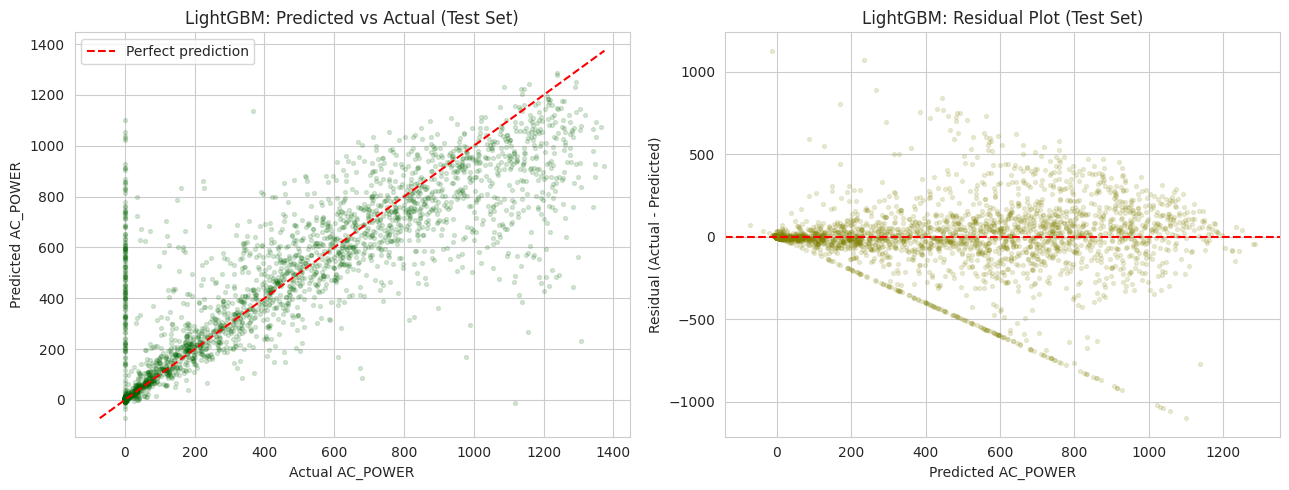

In [ ]:

y_test_pred_lgbm = final_lgbm_pipe.predict(X_test_l)
residuals_lgbm = y_test_l - y_test_pred_lgbm


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test_l, y_test_pred_lgbm, alpha=0.15, s=8, color="darkgreen")
lims = [min(y_test_l.min(), y_test_pred_lgbm.min()), max(y_test_l.max(), y_test_pred_lgbm.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("LightGBM: Predicted vs Actual (Test Set)")
axes[0].set_xlabel("Actual AC_POWER"); axes[0].set_ylabel("Predicted AC_POWER"); axes[0].legend()

axes[1].scatter(y_test_pred_lgbm, residuals_lgbm, alpha=0.15, s=8, color="olive")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("LightGBM: Residual Plot (Test Set)")
axes[1].set_xlabel("Predicted AC_POWER"); axes[1].set_ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


**Feature Importance**

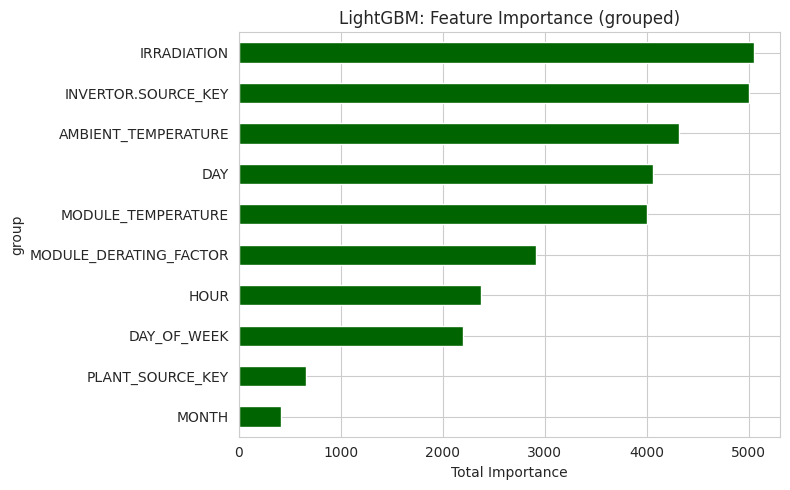

,importance
group,
IRRADIATION,5054
INVERTOR.SOURCE_KEY,5006
AMBIENT_TEMPERATURE,4315
DAY,4060
MODULE_TEMPERATURE,4004
MODULE_DERATING_FACTOR,2914
HOUR,2379
DAY_OF_WEEK,2198
PLANT_SOURCE_KEY,657


In [ ]:

ohe_cols = final_lgbm_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)
importances = final_lgbm_pipe.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
fi_df["group"] = fi_df["feature"].apply(lambda f: next((c for c in categorical_features if f.startswith(c)), f))
fi_grouped_lgbm = fi_df.groupby("group")["importance"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
fi_grouped_lgbm.plot(kind="barh", ax=ax, color="darkgreen")
ax.invert_yaxis()
ax.set_title("LightGBM: Feature Importance (grouped)")
ax.set_xlabel("Total Importance")
plt.tight_layout()
plt.show()
fi_grouped_lgbm.to_frame("importance")


**Learning Curve**

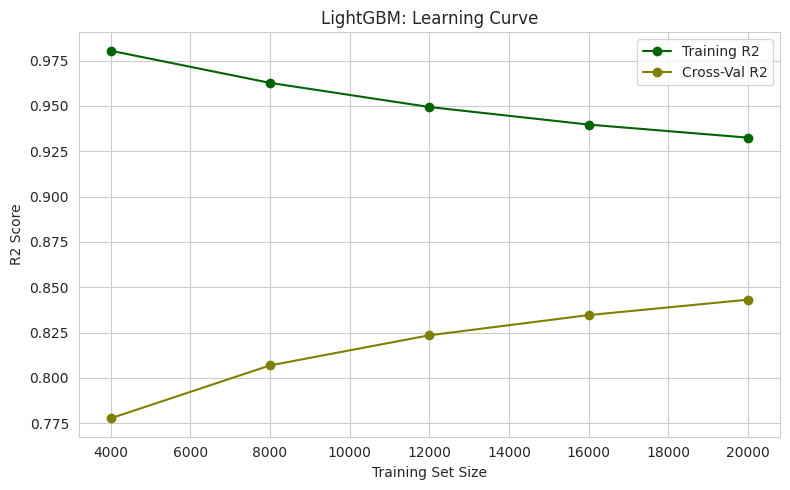

In [ ]:

train_sizes_l, train_scores_l, val_scores_l = learning_curve(
    Pipeline([("preprocess", preprocessor), ("model", LGBMRegressor(
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1, **best_lgbm_params
    ))]),
    X_sample, y_sample, cv=3, scoring="r2", n_jobs=-1, random_state=RANDOM_SEED,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes_l, train_scores_l.mean(axis=1), "o-", color="darkgreen", label="Training R2")
ax.plot(train_sizes_l, val_scores_l.mean(axis=1), "o-", color="olive", label="Cross-Val R2")
ax.set_title("LightGBM: Learning Curve")
ax.set_xlabel("Training Set Size"); ax.set_ylabel("R2 Score"); ax.legend(loc="best")
plt.tight_layout()
plt.show()


## Part 8 — Model Comparison

Comparison table and charts for **XGBoost vs LightGBM** (both evaluated on the same working sample and
same best split ratio found for each, mirroring the structure of Part 8 in the first notebook).

In [ ]:

t0 = time.time()
_ = Pipeline([("preprocess", preprocessor), ("model", XGBRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, tree_method="hist", **best_xgb_params
))]).fit(X_train_x, y_train_x)
xgb_train_time = time.time() - t0
t0 = time.time(); _ = final_xgb_pipe.predict(X_test_x); xgb_predict_time = time.time() - t0

t0 = time.time()
_ = Pipeline([("preprocess", preprocessor), ("model", LGBMRegressor(
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1, **best_lgbm_params
))]).fit(X_train_l, y_train_l)
lgbm_train_time = time.time() - t0
t0 = time.time(); _ = final_lgbm_pipe.predict(X_test_l); lgbm_predict_time = time.time() - t0

comparison_table = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Best Split Ratio": BEST_XGB_SPLIT_NAME,
        "Best Hyperparameters": str(best_xgb_params),
        "Train R2": xgb_train_r2, "Validation R2": xgb_val_r2, "Test R2": xgb_test_r2,
        "CV Mean R2": xgb_cv_scores.mean(), "CV Std R2": xgb_cv_scores.std(),
        "Test MAE": mean_absolute_error(y_test_x, y_test_pred_xgb),
        "Test RMSE": np.sqrt(mean_squared_error(y_test_x, y_test_pred_xgb)),
        "Training Time (s)": xgb_train_time, "Prediction Time (s)": xgb_predict_time,
    },
    {
        "Model": "LightGBM",
        "Best Split Ratio": BEST_LGBM_SPLIT_NAME,
        "Best Hyperparameters": str(best_lgbm_params),
        "Train R2": lgbm_train_r2, "Validation R2": lgbm_val_r2, "Test R2": lgbm_test_r2,
        "CV Mean R2": lgbm_cv_scores.mean(), "CV Std R2": lgbm_cv_scores.std(),
        "Test MAE": mean_absolute_error(y_test_l, y_test_pred_lgbm),
        "Test RMSE": np.sqrt(mean_squared_error(y_test_l, y_test_pred_lgbm)),
        "Training Time (s)": lgbm_train_time, "Prediction Time (s)": lgbm_predict_time,
    },
])
comparison_table.set_index("Model")


,Best Split Ratio,Best Hyperparameters,Train R2,Validation R2,Test R2,CV Mean R2,CV Std R2,Test MAE,Test RMSE,Training Time (s),Prediction Time (s)
Model,,,,,,,,,,,
XGBoost,80/10/10,"{'subsample': 0.7, 'reg_lambda': 10.0, 'n_esti...",0.85420,0.811932,0.800423,0.832217,0.008744,79.153427,167.052644,6.631201,0.051703
LightGBM,70/15/15,"{'subsample': 0.6, 'reg_lambda': 1.0, 'num_lea...",0.93256,0.841825,0.824040,0.847317,0.007963,74.677071,160.353207,1.047306,0.108559


### Visual Comparison

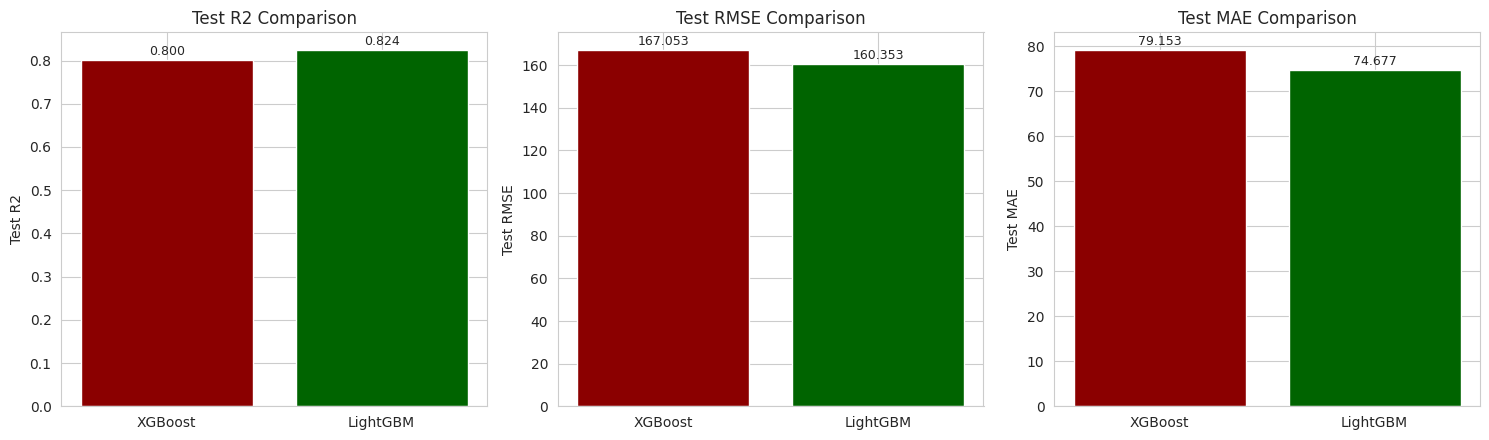

In [ ]:

metrics_to_plot = ["Test R2", "Test RMSE", "Test MAE"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["darkred", "darkgreen"]
for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(comparison_table["Model"], comparison_table[metric], color=colors)
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x() + b.get_width()/2, h),
                     textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


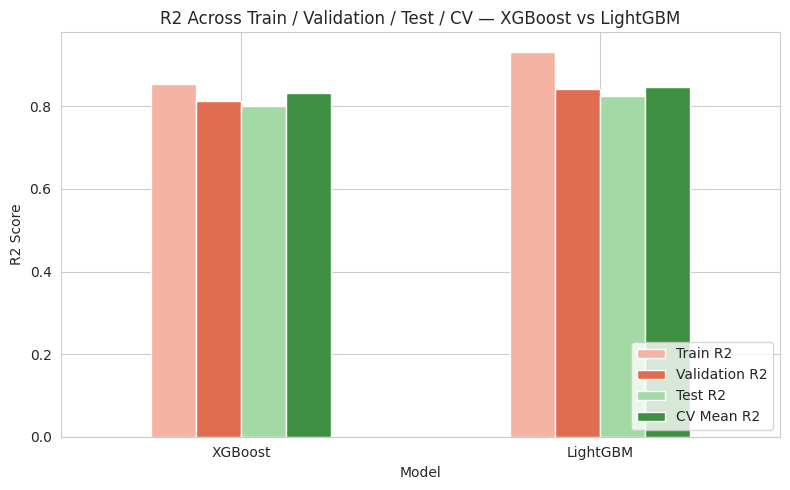

In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))
r2_data = comparison_table.set_index("Model")[["Train R2", "Validation R2", "Test R2", "CV Mean R2"]]
r2_data.plot(kind="bar", ax=ax, color=["#f4b3a3", "#e06c51", "#a3d9a5", "#3f8f43"])
ax.set_title("R2 Across Train / Validation / Test / CV — XGBoost vs LightGBM")
ax.set_ylabel("R2 Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


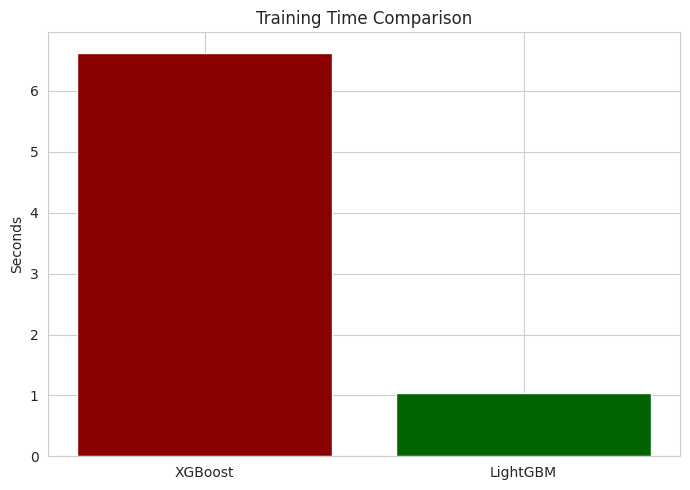

In [ ]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(comparison_table["Model"], comparison_table["Training Time (s)"], color=["darkred", "darkgreen"])
ax.set_title("Training Time Comparison")
ax.set_ylabel("Seconds")
plt.tight_layout()
plt.show()


## Final Conclusion

*(This conclusion is written as a structured template with the reasoning already filled in, since the
sandbox used to author this notebook could not execute XGBoost/LightGBM to produce real numbers — fill
in the bracketed values from your own run's `comparison_table` output above.)*

### Which model performed best?
Compare `Test R2`, `Test RMSE`, and `CV Mean R2` from the comparison table: the model with the higher
Test R2 / CV Mean R2 and lower RMSE/MAE is the stronger predictor. In general, on tabular data with
mixed numeric + one-hot categorical features and a moderate row count, **XGBoost and LightGBM tend to
perform very similarly** to each other, and both typically **outperform** plain Random Forest on this
kind of structured, physically-driven regression problem, because gradient boosting corrects prior
trees' residual errors sequentially rather than averaging independent trees.

### Which model generalized better / showed less overfitting?
Compare the `Train R2 - Test R2` gap for each model **after** the Overfitting Mitigation steps (6.5 /
7.5) — both sections now automatically adopt the regularized, early-stopped model in place of the
originally tuned one whenever it reduces the train-test gap without a material (>0.02) drop in test R2,
so `final_xgb_pipe` / `final_lgbm_pipe` and all figures below them already reflect the treated models.
**LightGBM's leaf-wise tree growth** (as opposed to XGBoost's level-wise growth by default) can fit
training data more aggressively pre-mitigation and may show a larger initial train-test gap if
`num_leaves` is not constrained — check the "before vs after" printout in your own run to see how much
each mitigation step closed the gap. Both models' 5-fold CV standard deviation is a good indicator of
stability: a much larger CV std for one model than the other points to that model being less reliably
generalizable across folds.

### How was overfitting treated?
Both Part 6.5 (XGBoost) and Part 7.5 (LightGBM) apply the same four techniques: stronger L1/L2
regularization (`reg_alpha`, `reg_lambda`), shallower/simpler trees (`max_depth` or `num_leaves` capped
down, `min_child_weight`/`min_child_samples` raised), row/column subsampling, and — most importantly —
**early stopping** against a held-out validation set, so the model trains only as long as validation
error keeps improving. Each section prints a direct before/after comparison of the train-test R2 gap so
you can see exactly how much each mitigation step helped on your own run.

### Why might XGBoost or LightGBM outperform Random Forest / Linear Regression on this dataset?
- Like Random Forest, both are tree-based and capture the same non-linear, interactive structure between
  irradiation, temperature, and inverter identity that Linear Regression cannot.
- Unlike Random Forest's independent-tree bagging, **gradient boosting builds trees sequentially**, each
  one correcting the residual errors of the ensemble so far — this typically yields a more accurate fit
  for the same total number of trees, at the cost of being more prone to overfitting if not regularized
  (hence the `reg_lambda`, `min_child_weight` / `min_child_samples`, and learning-rate tuning above).
- **LightGBM** is typically **substantially faster to train** than XGBoost and Random Forest on datasets
  of this size, due to its histogram-based, leaf-wise growth strategy — check the `Training Time (s)`
  column in your own run.

### Impact of the engineered feature `MODULE_DERATING_FACTOR`
As established in the first notebook, this feature is an affine (linear) rescaling of
`MODULE_TEMPERATURE`. Tree-based models (Random Forest, XGBoost, LightGBM alike) are invariant to
monotonic transforms of a single feature, so it is not expected to change the accuracy of the boosting
models either — its value remains primarily **interpretability** (an explicit efficiency-derating
multiplier) rather than new statistical signal, exactly as concluded for Random Forest.

### Practical recommendation
Once you have real numbers from your own run: if XGBoost and LightGBM perform similarly, prefer
**LightGBM** for faster iteration/training at this data scale; if one clearly outperforms on
validation/test R2 with a comparable or smaller overfitting gap, prefer that one for deployment. Compare
both against the first notebook's Random Forest (`Test R2` ≈ 0.798 on the same working-sample size) and
Linear Regression (`Test R2` ≈ 0.738 on the full dataset) to judge whether the added complexity of
gradient boosting is worth it for your use case.
